In [1]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing 
from statsmodels.tsa.holtwinters import ExponentialSmoothing 
from statsmodels.tsa.holtwinters import Holt 
import pandas as pd
import numpy as np
import os
import sys


In [2]:
df = pd.read_csv("/Applications/Work Space/Python Work Space/python_forcesting/airline_passengers.csv", index_col="Month", parse_dates=True)
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [3]:
holt_winters = ExponentialSmoothing(df["Passengers"], 
                          initialization_method="legacy-heuristic", 
                          trend="add", 
                          seasonal="add", 
                          seasonal_periods=12)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [4]:
res_hw = holt_winters.fit()

In [5]:
df["HoltWinters"] = res_hw.fittedvalues

<Axes: xlabel='Month'>

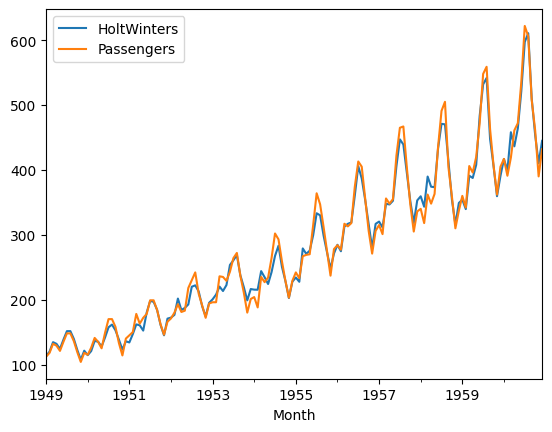

In [6]:
df[["HoltWinters", "Passengers"]].plot()

In [7]:
N_test = 12
train = df.iloc[:-N_test]
test = df.iloc[-N_test:]

In [8]:
train_idx = df.index <= train.index[-1]
test_idx = df.index > train.index[-1]

## Holt Winters Model - 1

In [9]:
holt_winters_train = ExponentialSmoothing(train["Passengers"], 
                          initialization_method="legacy-heuristic", 
                          trend="add", 
                          seasonal="add", 
                          seasonal_periods=12)

res_hw_train =  holt_winters_train.fit()


df.loc[train_idx, "HoltWinters_1"] = res_hw_train.fittedvalues
df.loc[test_idx, "HoltWinters_1"] = res_hw_train.forecast(N_test)
df

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,Passengers,HoltWinters,HoltWinters_1
Month,,,
1949-01-01,112,113.083333,113.083333
1949-02-01,118,119.882528,119.883179
1949-03-01,132,134.461924,134.463068
1949-04-01,129,131.871654,131.872693
1949-05-01,121,124.150773,124.150908
...,...,...,...
1960-08-01,606,610.803665,605.647911
1960-09-01,508,510.249902,506.175719
1960-10-01,461,453.789694,450.148473


<Axes: xlabel='Month'>

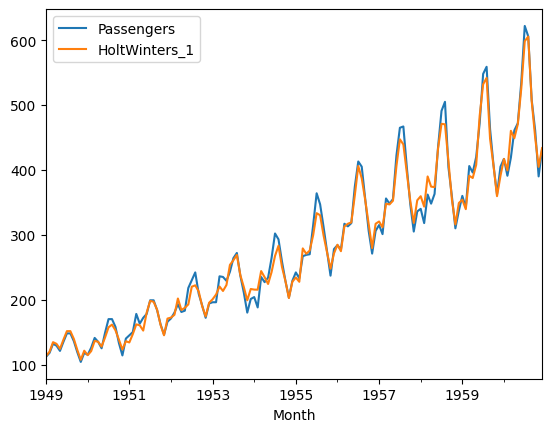

In [10]:
df[["Passengers", "HoltWinters_1"]].plot()

In [11]:
def rmse(y, t):
    return np.sqrt(np.mean(y - t)**2)


def mae(y, t):
    return np.mean(np.abs(y - t))

In [12]:
print("Train RMSE:" , rmse(train["Passengers"], res_hw_train.fittedvalues))
print("Test RMSE:" , rmse(test["Passengers"], res_hw_train.forecast(N_test)))


Train RMSE: 1.6870741782538328
Test RMSE: 0.5523888391015722


In [13]:
print("Train MAE:" , mae(train["Passengers"], res_hw_train.fittedvalues))
print("Test MAE:" , mae(test["Passengers"], res_hw_train.forecast(N_test)))


Train MAE: 8.892112773042472
Test MAE: 10.437502293568826


##  Holt Winters Model - 2

In [18]:
holt_winters_train_2 = ExponentialSmoothing(train["Passengers"], 
                          initialization_method="legacy-heuristic", 
                          trend="add", 
                          seasonal="mul", 
                          seasonal_periods=12)

res_hw_train_2 =  holt_winters_train_2.fit()


df.loc[train_idx, "HoltWinters_2"] = res_hw_train_2.fittedvalues
df.loc[test_idx, "HoltWinters_2"] = res_hw_train_2.forecast(N_test)
df

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,Passengers,HoltWinters,HoltWinters_1,HoltWinters_2
Month,,,,
1949-01-01,112,113.083333,113.083333,112.537305
1949-02-01,118,119.882528,119.883179,118.944240
1949-03-01,132,134.461924,134.463068,133.330491
1949-04-01,129,131.871654,131.872693,130.465654
1949-05-01,121,124.150773,124.150908,122.462310
...,...,...,...,...
1960-08-01,606,610.803665,605.647911,635.725537
1960-09-01,508,510.249902,506.175719,521.668718
1960-10-01,461,453.789694,450.148473,456.578839


<Axes: xlabel='Month'>

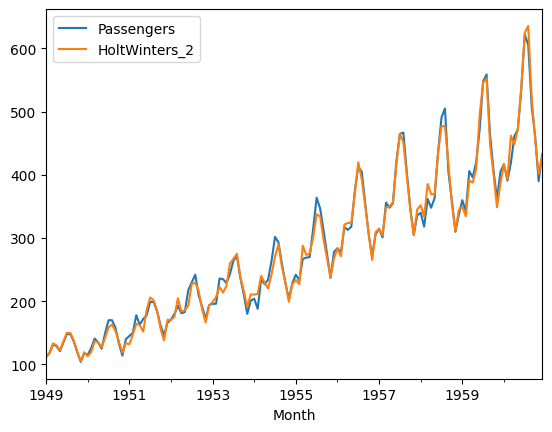

In [19]:
df[["Passengers", "HoltWinters_2"]].plot()

In [20]:
print("Train RMSE:" , rmse(train["Passengers"], res_hw_train_2.fittedvalues))
print("Test RMSE:" , rmse(test["Passengers"], res_hw_train_2.forecast(N_test)))


Train RMSE: 1.718624913982844
Test RMSE: 7.1757991292415015


In [ ]:
print("Train RMSE:" , rmse(train["Passengers"], res_hw_train_2.fittedvalues))
print("Test RMSE:" , rmse(test["Passengers"], res_hw_train_2.forecast(N_test)))


Train MAE: 7.55205253266076
Test MAE: 10.683342099494004


##  Holt Winters Model - 3

In [24]:
holt_winters_train_3 = ExponentialSmoothing(train["Passengers"], 
                          initialization_method="legacy-heuristic", 
                          trend="mul", 
                          seasonal="mul", 
                          seasonal_periods=12)

res_hw_train_3 =  holt_winters_train_3.fit()


df.loc[train_idx, "HoltWinters_3"] = res_hw_train_3.fittedvalues
df.loc[test_idx, "HoltWinters_3"] = res_hw_train_3.forecast(N_test)
df

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,Passengers,HoltWinters,HoltWinters_1,HoltWinters_2,HoltWinters_3
Month,,,,,
1949-01-01,112,113.083333,113.083333,112.537305,112.915586
1949-02-01,118,119.882528,119.883179,118.944240,119.635195
1949-03-01,132,134.461924,134.463068,133.330491,134.349264
1949-04-01,129,131.871654,131.872693,130.465654,131.646893
1949-05-01,121,124.150773,124.150908,122.462310,123.708876
...,...,...,...,...,...
1960-08-01,606,610.803665,605.647911,635.725537,641.958114
1960-09-01,508,510.249902,506.175719,521.668718,527.411291
1960-10-01,461,453.789694,450.148473,456.578839,462.326500


<Axes: xlabel='Month'>

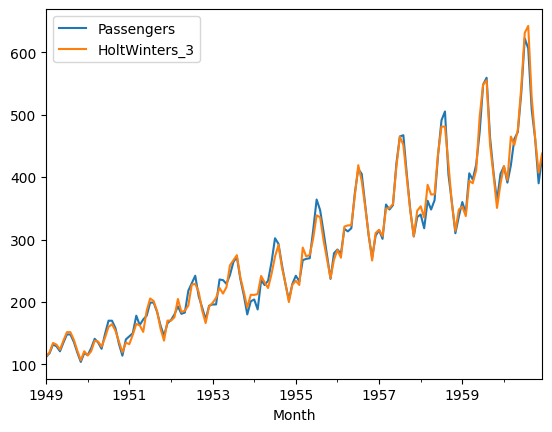

In [25]:
df[["Passengers", "HoltWinters_3"]].plot()

In [ ]:
print("Train RMSE:" , rmse(train["Passengers"], res_hw_train_3.fittedvalues))
print("Test RMSE:" , rmse(test["Passengers"], res_hw_train_3.forecast(N_test)))


Train RMSE: 0.8907828115510694
Test RMSE: 11.857481306809484


In [27]:
print("Train MAE:" , mae(train["Passengers"], res_hw_train_3.fittedvalues))
print("Test MAE:" , mae(test["Passengers"], res_hw_train_3.forecast(N_test)))


Train MAE: 7.408706075752775
Test MAE: 13.450533693042743


##  Holt Winters Model - 4

In [ ]:
holt_winters_train_4 = ExponentialSmoothing(train["Passengers"], 
                        initialization_method="legacy-heuristic", 
                        trend="mul", 
                        seasonal="add", 
                        seasonal_periods=12)

res_hw_train_4 =  holt_winters_train_4.fit()


df.loc[train_idx, "HoltWinters_4"] = res_hw_train_4.fittedvalues
df.loc[test_idx, "HoltWinters_4"] = res_hw_train_4.forecast(N_test)
df

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,Passengers,HoltWinters,HoltWinters_1,HoltWinters_2,HoltWinters_3,HoltWinters_4
Month,,,,,,
1949-01-01,112,113.083333,113.083333,112.537305,112.915586,113.846035
1949-02-01,118,119.882528,119.883179,118.944240,119.635195,121.251351
1949-03-01,132,134.461924,134.463068,133.330491,134.349264,136.318948
1949-04-01,129,131.871654,131.872693,130.465654,131.646893,134.127766
1949-05-01,121,124.150773,124.150908,122.462310,123.708876,126.738304
...,...,...,...,...,...,...
1960-08-01,606,610.803665,605.647911,635.725537,641.958114,615.359735
1960-09-01,508,510.249902,506.175719,521.668718,527.411291,517.154768
1960-10-01,461,453.789694,450.148473,456.578839,462.326500,462.381925


<Axes: xlabel='Month'>

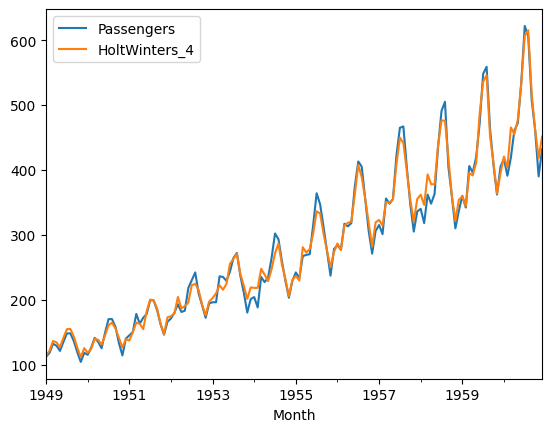

In [29]:
df[["Passengers", "HoltWinters_4"]].plot()

In [30]:
print("Train RMSE:" , rmse(train["Passengers"], res_hw_train_4.fittedvalues))
print("Test RMSE:" , rmse(test["Passengers"], res_hw_train_4.forecast(N_test)))


Train RMSE: 1.1025949273932603
Test RMSE: 9.43107882276413


In [31]:
print("Train MAE:" , mae(train["Passengers"], res_hw_train_4.fittedvalues))
print("Test MAE:" , mae(test["Passengers"], res_hw_train_4.forecast(N_test)))


Train MAE: 8.906215050396703
Test MAE: 13.192988979655075
